## IndoorCO2Map Original Database

<iframe src="https://indoorco2map.com/?lat=19.34553&lng=4.50000&zoom=1.37" 
        loading="lazy" 
        style="width: 100%; height: 650px; border: 1px solid #ccc;" 
        allowfullscreen>
</iframe>

**Reference:** Indoor $CO_2$ Map Project. (n.d.). Retrieved on September 29 - 2025,  https://indoorco2map.com/


# Librerias

In [ ]:
#Librerias Basicas
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import folium
from folium.plugins import HeatMap

#Librerios para imputar
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder

#Librerias para particionar y validar
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold

#Librerias para metricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay, classification_report
from scipy.stats import kstest, zscore, kruskal, chi2_contingency

#Librerias de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from scipy.signal import savgol_filter
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D  
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RandomState = 42

# Cargar Datos

In [2]:
# Load data from a JSON file and convert it into a pandas DataFrame
class DataLoad:
    def __init__(self, url):
        self.url = url

    def __call__(self):
        response = requests.get(self.url)
        response.raise_for_status() 
        data = response.json()
        df = pd.DataFrame(data)
        return df


url = "https://raw.githubusercontent.com/Yeikeer/IndoorCO2Map-Analysis/main/Lab%201/indoorco2mapData.json"


indoorco2map = DataLoad(url)()

indoorco2map["co2readingsMed"] = indoorco2map["co2readings"].apply(np.median)

print(f'\nDataFrame columns: {indoorco2map.columns.tolist()}\n') # Print the column names of the DataFrame
indoorco2map.shape


DataFrame columns: ['nwrtype', 'nwrID', 'name', 'latitude', 'longitude', 'countryID', 'countryName', 'nuts3ID', 'nuts3Name', 'osmKey', 'osmTag', 'brand', 'startOfMeasurement', 'windowsOpen', 'ventilationSystem', 'customNotes', 'co2readings', 'offset', 'interval', 'co2readingsAvg', 'co2readingsMed']



(12681, 21)

# Filtrar Datos

In [3]:
class DataCleaner:
    def __init__(self, df):
        self.df = df

    def __call__(self, method="mean"):

        # clean empty strings and common NaN representations of pandas and numpy null values
        self.df = self.df.replace(
            [r'^\s*$', 'NaN', 'nan', 'NAN', 'N/A', 'None', None],
            np.nan,
            regex=True
        )

        # Identify columns with list or dict types to exclude them from imputation
        list_cols = [
            col for col in self.df.columns 
            if self.df[col].apply(lambda x: isinstance(x, (list, dict))).any()
        ]

        # numeric columns imputation
        num_cols = self.df.select_dtypes(include='number').columns.difference(list_cols)
        if method == "mean":
            self.df[num_cols] = self.df[num_cols].fillna(self.df[num_cols].mean())
        elif method == "median":
            self.df[num_cols] = self.df[num_cols].fillna(self.df[num_cols].median())
        else:
            raise ValueError('Use mean or median')

        # string/categorical columns imputation
        cat_cols = self.df.select_dtypes(exclude=['number']).columns.difference(list_cols)
        for col in cat_cols:
            mode_series = self.df[col].mode()
            if not mode_series.empty:
                self.df[col].fillna(mode_series.iloc[0], inplace=True)

        return self.df

In [4]:
# aplly data cleaning class
cleaner = DataCleaner(indoorco2map)
indoorco2map = cleaner("mean")

# Verify no missing values remain
indoorco2map.isnull().sum()
indoorco2map

C:\Users\mlondono\AppData\Local\Temp\ipykernel_19572\3388264166.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[col].fillna(mode_series.iloc[0], inplace=True)


,nwrtype,nwrID,name,latitude,longitude,countryID,countryName,nuts3ID,nuts3Name,osmKey,...,brand,startOfMeasurement,windowsOpen,ventilationSystem,customNotes,co2readings,offset,interval,co2readingsAvg,co2readingsMed
0,n,4436021034,Konsum,51.340164,12.366027,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,Konsum Leipzig,2024-05-15T17:10:19.811,False,True,1. Etage,"[544, 573, 547, 533, 595, 601]",0,1,566,560.0
1,n,386028187,Konsum Leipzig,51.300839,12.397328,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,Konsum Leipzig,2024-05-16T10:27:41.828,False,True,1. Etage,"[680, 672, 640, 661, 651]",0,1,661,661.0
2,n,1706619258,Konsum,51.278852,12.369599,DEU,Germany,DED52,Leipzig,shop,...,Konsum Leipzig,2024-05-17T10:44:03.095,True,True,1. Etage,"[897, 903, 985, 998, 871, 959]",0,1,936,931.0
3,w,248962888,REWE,51.310976,12.373789,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,REWE,2024-04-15T19:24:48.298,False,True,1. Etage,"[1202, 1568, 1689, 1690, 1703, 1607]",0,1,1576,1648.0
4,n,4271724130,Konsum,51.311495,12.379476,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,Konsum Leipzig,2024-04-11T18:08:34.631,False,True,1. Etage,"[549, 711, 746, 738, 776, 790, 761]",0,1,724,746.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12676,n,4018242621,Orthopädie Müller,49.591057,11.004864,DEU,Germany,DE252,"Erlangen, Kreisfreie Stadt",shop,...,REWE,2025-09-02T07:14:17.918,False,False,1. Etage,"[552, 553, 560, 557, 570, 565, 559, 559, 541, ...",0,1,558,559.0
12677,w,439643389,Norma,49.545244,11.028314,DEU,Germany,DE252,"Erlangen, Kreisfreie Stadt",shop,...,NORMA,2025-09-02T07:47:59.269,False,False,1. Etage,"[769, 892, 962, 955, 995, 1002, 901, 974, 1118]",0,1,952,962.0
12678,n,9353786402,Rewe,54.341743,13.739639,DEU,Germany,DE80L,Vorpommern-Rügen,shop,...,Rewe,2025-09-02T08:49:29.938,False,False,1. Etage,"[806, 815, 796, 786, 782, 781, 842, 861, 860, ...",3,1,817,815.0
12679,n,7089534833,Subway,51.315186,12.373109,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",amenity,...,Subway,2025-09-02T10:51:27.497,False,False,1. Etage,"[610, 599, 627, 612, 624, 627, 635, 648, 642]",2,1,625,627.0


## Crear Datos Estadisticos

In [5]:
#Create a news stadistic columns 

class FeatureExtractor:
    def __init__(self, df, list_col):
        self.df = df
        self.list_col = list_col

    def __call__(self, prefix=None):

        if prefix is None:
            prefix = self.list_col

        self.df[f"{prefix}Med"] = self.df[self.list_col].apply(np.median)
        self.df[f"{prefix}Std"] = self.df[self.list_col].apply(np.std)
        self.df[f"{prefix}Var"] = self.df[self.list_col].apply(np.var)
        self.df[f"{prefix}Min"] = self.df[self.list_col].apply(np.min)
        self.df[f"{prefix}Max"] = self.df[self.list_col].apply(np.max)
        self.df[f"{prefix}Range"] = self.df[self.list_col].apply(lambda x: np.max(x) - np.min(x))
        self.df[f"{prefix}RMS"] = self.df[self.list_col].apply(lambda x: np.sqrt(np.mean(np.square(x))))
        self.df[f"{prefix}CV"] = self.df[f"{prefix}Std"] / self.df[f"{prefix}Med"]

        return self.df


In [6]:
extractor = FeatureExtractor(indoorco2map, "co2readings")
indoorco2map = extractor()

In [7]:

class TimeSeries:
    def __init__(self, df):
        self.df = df

    def __call__(self, readings_col, start_col, interval_col, absolute=True): #True absolute time, False relative time

        def build_times(row):
            readings = row[readings_col]
            interval = row[interval_col]
            if not isinstance(readings, list) or len(readings) == 0:
                return np.nan
            if pd.isna(interval) or interval <= 0:
                return np.nan
            
            dt = interval * 60.0 
            rel_times = np.arange(0, len(readings) * dt, dt)
            
            if absolute:
                start_time = pd.to_datetime(row[start_col])
                abs_times = [start_time + pd.to_timedelta(t, unit='s') for t in rel_times]
                return abs_times
            else:
                return list(rel_times)

        self.df["time_list"] = self.df.apply(build_times, axis=1)
        return self.df

In [8]:
timebuild = TimeSeries(indoorco2map)
indoorco2map = timebuild("co2readings", "startOfMeasurement", "interval")
indoorco2map['TimeAvg'] = indoorco2map['co2readings'].apply(lambda x: np.mean(x) if isinstance(x, list) and len(x) > 0 else np.nan)
indoorco2map['TimeMed'] = indoorco2map['co2readings'].apply(lambda x: np.median(x) if isinstance(x, list) and len(x) > 0 else np.nan)


In [9]:

class TemporalFeatureExtractor:

    def __init__(self, df, co2_col, time_col):
        self.df = df
        self.co2_col = co2_col
        self.time_col = time_col

    def convert_s(self, time_list):
        if not isinstance(time_list, list) or len(time_list) < 2:
            return None
        try:
            t = pd.to_datetime(time_list)
            return np.array([(ti - t[0]).total_seconds() for ti in t])
        except Exception:
            return None

    def __call__(self):
        def safe_polyfit(t, y, deg):
            try:
                if t is None or len(t) < 3:
                    return np.nan
                return np.polyfit(t, y, deg)[0]
            except Exception:
                return np.nan

        self.df["co2readingsSlope"] = self.df.apply(
            lambda r: safe_polyfit(self.convert_s(r[self.time_col]), r[self.co2_col], 1),
            axis=1
        )

        self.df["co2readingsCurvature"] = self.df.apply(
            lambda r: safe_polyfit(self.convert_s(r[self.time_col]), r[self.co2_col], 2),
            axis=1
        )

        self.df["co2readingsMean_diff"] = self.df[self.co2_col].apply(
            lambda x: np.mean(np.abs(np.diff(x))) if isinstance(x, list) and len(x) > 1 else np.nan
        )

        self.df["co2readingsStd_diff"] = self.df[self.co2_col].apply(
            lambda x: np.std(np.diff(x)) if isinstance(x, list) and len(x) > 1 else np.nan
        )

        return self.df

In [10]:
temporal_extractor = TemporalFeatureExtractor(indoorco2map, "co2readings", "time_list")
indoorco2map = temporal_extractor()

In [11]:
# Class for printing value counts and sizes of DataFrame columns
class DataPrint:
    def __init__(self, df):
        self.df = df

    def __call__(self, columns):

        for col in columns:
            if col not in self.df.columns:
                print(f'The column {col} does not exist in the DataFrame.\n')
                continue

            counts = self.df[col].value_counts(dropna=False)
            total = len(self.df[col])
            print(f'\n{counts}')
            print(f'Size: {total}\n')
            

In [12]:
# print some value counts 
inspector = DataPrint(indoorco2map)
cols_car = [
    "buildingType",
    "windowsOpen",
    "ventilationSystem",
    "brand",
    "osmTag",
    "osmKey",
    "countryName"]
inspector(cols_car)

The column buildingType does not exist in the DataFrame.


windowsOpen
False    11921
True       760
Name: count, dtype: int64
Size: 12681


ventilationSystem
False    11593
True      1088
Name: count, dtype: int64
Size: 12681


brand
REWE               5861
EDEKA               592
Lidl                474
dm                  327
ALDI Süd            199
                   ... 
Dollarama             1
Bachmann              1
Naturalia Vegan       1
Kempinski             1
porta                 1
Name: count, Length: 685, dtype: int64
Size: 12681


osmTag
supermarket                   5043
chemist                        659
restaurant                     520
fast_food                      412
cafe                           345
                              ... 
paint;trade                      1
tyres                            1
audiologist                      1
garden_centre;doityourself       1
bell                             1
Name: count, Length: 194, dtype: int64
Size: 12681


osm

In [13]:
def classify_ventilation(row):
    mech = str(row["ventilationSystem"]).strip().lower() == "true"
    nat = str(row["windowsOpen"]).strip().lower() == "true"
    
    if mech and nat:
        return "both"
    elif mech:
        return "mechanical"
    elif nat:
        return "natural"
    else:
        return "none"

indoorco2map["ventilation_type"] = indoorco2map.apply(classify_ventilation, axis=1)

ventilation_medians = (
    indoorco2map.groupby("ventilation_type")["co2readingsMed"]
    .median()
    .reset_index()
    .rename(columns={"co2readingsMed": "Median_CO2"})
    .sort_values("Median_CO2", ascending=False)
)

# Visualizacion Datos

                 countryName  count
0                    Germany   8348
1                    Austria   1243
2   United States of America    914
3             United Kingdom    532
4                Netherlands    294
5                     France    290
6                Switzerland    269
7                     Sweden    158
8                    Belgium     99
9                      Spain     79
10                     Italy     70
11                 Hong Kong     51
12                 Australia     46
13                   Denmark     44
14                    Canada     42
15                   Finland     28
16                    Norway     24
17                  Portugal     24
18                   Ireland     19
19                    Greece     17
20                    Poland     15
21                  Slovenia     11
22                  Thailand      9
23                 Singapore      9
24                 Indonesia      8
25                Luxembourg      6
26                  Slovakia

C:\Users\mlondono\AppData\Local\Temp\ipykernel_19572\1609056968.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


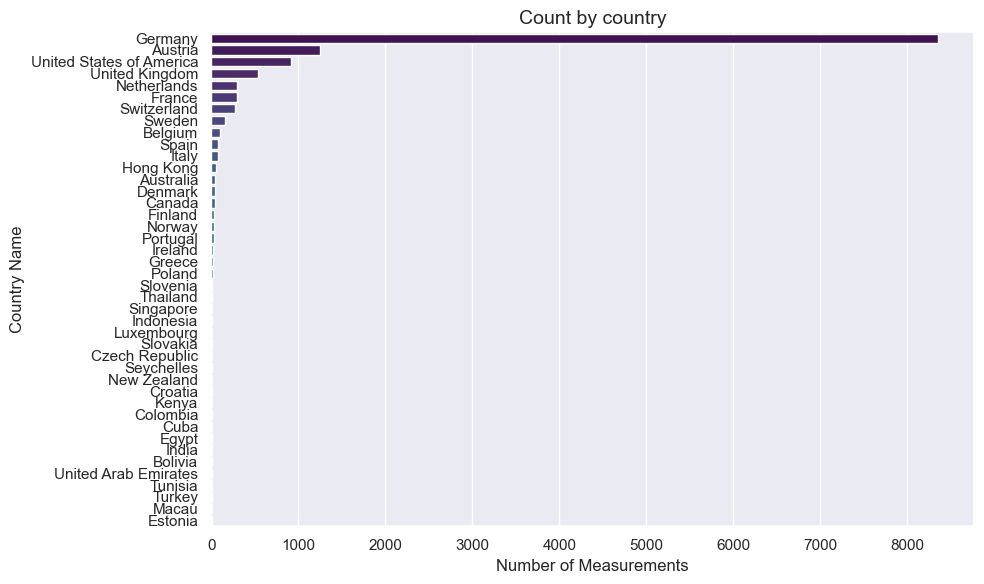

In [14]:
# Count occurrences of each country
country_counts = indoorco2map["countryName"].value_counts().reset_index()
country_counts.columns = ["countryName", "count"]
print(country_counts)

sns.set_theme(style="darkgrid")

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=country_counts,
    x="count", 
    y="countryName", 
    palette="viridis"
)

plt.title("Count by country", fontsize=14)
plt.xlabel("Number of Measurements")
plt.ylabel("Country Name")


plt.tight_layout()
plt.show()

In [15]:
# Filter countries with more than 10 records
top_countries = country_counts[country_counts["count"] > 10]["countryName"]
filtered_df = indoorco2map[indoorco2map["countryName"].isin(top_countries)].copy()

# Average of averages CO2 by country
co2_avg_country = (
    filtered_df.groupby("countryName")["co2readingsAvg"]
    .mean()
    .reset_index()
    .rename(columns={"countryName": "Country", "co2readingsAvg": "Avg_CO2"})
)
co2_avg_country = co2_avg_country.sort_values(by="Avg_CO2", ascending=True)
print(co2_avg_country)


# Dowload GeoJSON data for world countries
url = "https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json"
world_geo = requests.get(url).json()

m2 = folium.Map(location=[20, 0], zoom_start=2)

# colors 
folium.Choropleth(
    geo_data=world_geo,
    data=co2_avg_country,
    columns=["Country", "Avg_CO2"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",       
    fill_opacity=0.7,
    line_opacity=0.2,
    nan_fill_color="lightgrey",
    legend_name=""
).add_to(m2)

# show the map in the nex markdown cell
m2.save("mapa_co2_prom.html")


                     Country      Avg_CO2
13                    Norway   596.625000
17                     Spain   628.126582
5                    Finland   637.250000
18                    Sweden   661.069620
10                   Ireland   754.684211
15                  Portugal   756.041667
3                     Canada   768.476190
4                    Denmark   772.659091
20            United Kingdom   793.776316
0                  Australia   796.891304
9                  Hong Kong   799.568627
12               Netherlands   805.384354
19               Switzerland   817.096654
11                     Italy   829.085714
6                     France   842.793103
21  United States of America   868.781182
1                    Austria   878.191472
7                    Germany   880.566004
16                  Slovenia   886.363636
2                    Belgium   912.555556
8                     Greece   993.529412
14                    Poland  1203.933333


<iframe src="https://yeikeer.github.io/IndoorCO2Map-Analysis/mapa_co2_prom.html" width="100%" height="600"></iframe>

C:\Users\mlondono\AppData\Local\Temp\ipykernel_19572\3120898060.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


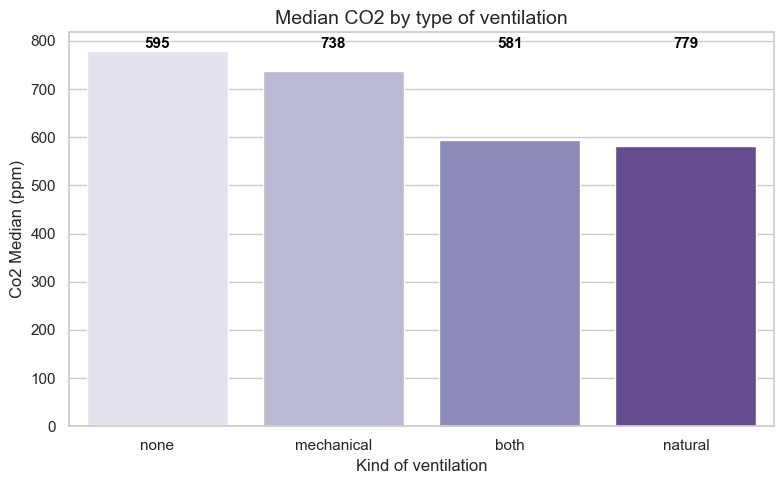

In [16]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

#Colors palette
palette = sns.color_palette("Purples", n_colors=len(ventilation_medians))

ax = sns.barplot(
    data=ventilation_medians,
    x="ventilation_type",
    y="Median_CO2",
    palette=palette
)

plt.title("Median CO2 by type of ventilation", fontsize=14)
plt.xlabel("Kind of ventilation")
plt.ylabel("Co2 Median (ppm)")

# Align and place text labels above bars
y_text = ventilation_medians["Median_CO2"].max() * 1.0

for i, row in ventilation_medians.iterrows():
    ax.text(i, y_text, f"{row['Median_CO2']:.0f}", 
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


# Seleccion Caracteristicas

## Numerical characteristics


| **Column** | **Operation applied** | **Interpretation / Usefulness** |
|-------------|-----------------------|----------------------------------|
| `co2readingsAvg` | Arithmetic mean of the $CO_2$ readings (**np.mean**) | Represents the average $CO_2$ level during the measurement period. Provides a general indication of air quality. |
| `co2readingsMed` | Median of the $CO_2$ readings (**np.median**) | A robust central value less sensitive to outliers. Indicates the “typical” $CO_2$ level during the sampling. |
| `co2readingsStd` | Standard deviation (**np.std**) | Measures how much the readings vary around the mean. High values indicate strong fluctuations in $CO_2$ concentration. |
| `co2readingsVar` | Variance (**np.var**) | Square of the standard deviation. Represents the overall magnitude of variability in the readings. |
| `co2readingsMin` | Minimum value (**np.min**) | The lowest $CO_2$ concentration recorded in the session. Useful for identifying periods of good ventilation. |
| `co2readingsMax` | Maximum value (**np.max**) | The highest $CO_2$ concentration recorded. Indicates possible accumulation events or peaks. |
| `co2readingsRange` | Difference between max and min (**np.max - np.min**) | Describes the range of variation in $CO_2$ levels during measurement. A wide range means strong temporal variability. |
| `co2readingsRMS` | Root Mean Square (**$\sqrt{meanX^{2}}$**) | Measures the average “energy level” of the $CO_2$ signal. Sensitive to high values, useful for comparing total magnitude. |
| `co2readingsCV` | Coefficient of Variation (**Std / Med**) | Relates variability to the median level. Allows comparing the relative stability of locations with different $CO_2$ magnitudes. |
| `co2readingsSlope` | Slope from a linear regression of $CO_2$ vs. time (**np.polyfit(..., 1))** | Indicates the temporal trend: positive = $CO_2$ buildup, negative = effective ventilation or decreasing concentration. |
| `co2readingsCurvature` | Quadratic coefficient from a 2nd-degree polynomial fit (**np.polyfit(..., 2)[0]**) | Measures the acceleration of the $CO_2$ trend. Positive = accelerating buildup; negative = deceleration. |
| `co2readingsMean_diff` | Mean absolute difference between consecutive readings (**mean($\Delta X $)**)| Quantifies the average magnitude of change between consecutive readings. Reflects temporal smoothness or fluctuation. |
| `co2readingsStd_diff` | Standard deviation of differences between consecutive readings (**std($\Delta X$)**) | Measures variability of the incremental changes. High values reflect oscillations or instability in air composition. |


| Type of statistic   | Examples                                      | They measure                                                                    |
| --------------------- | --------------------------------------------- | --------------------------------------------------------------------------- |
| **Absolute level**    | `Avg`, `Med`, `RMS`, `Max`, `Min`             | How high is the $CO_2$ level?.                                            |
| **Variability**      | `Std`, `Var`, `Range`, `CV`                   | How much do the measurements fluctuate?.                                          |
| **Temporal dynamics** | `Slope`, `Curvature`, `Mean_diff`, `Std_diff` | How $CO_2$ evolves over time (trend, acceleration, oscillations). |


In [17]:
indoorco2map

,nwrtype,nwrID,name,latitude,longitude,countryID,countryName,nuts3ID,nuts3Name,osmKey,...,co2readingsRMS,co2readingsCV,time_list,TimeAvg,TimeMed,co2readingsSlope,co2readingsCurvature,co2readingsMean_diff,co2readingsStd_diff,ventilation_type
0,n,4436021034,Konsum,51.340164,12.366027,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,566.096134,0.046380,"[2024-05-15 17:10:19.811000, 2024-05-15 17:11:...",565.500000,560.0,0.160476,0.001176,27.400000,31.442646,mechanical
1,n,386028187,Konsum Leipzig,51.300839,12.397328,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,660.954764,0.021638,"[2024-05-16 10:27:41.828000, 2024-05-16 10:28:...",660.800000,661.0,-0.115000,0.000972,17.750000,18.833149,mechanical
2,n,1706619258,Konsum,51.278852,12.369599,DEU,Germany,DED52,Leipzig,shop,...,936.711357,0.051152,"[2024-05-17 10:44:03.095000, 2024-05-17 10:45:...",935.500000,931.0,0.108095,-0.002113,63.200000,77.502516,both
3,w,248962888,REWE,51.310976,12.373789,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,1586.132981,0.105913,"[2024-04-15 19:24:48.298000, 2024-04-15 19:25:...",1576.500000,1648.0,1.157619,-0.013601,119.400000,158.226420,mechanical
4,n,4271724130,Konsum,51.311495,12.379476,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",shop,...,728.352250,0.101206,"[2024-04-11 18:08:34.631000, 2024-04-11 18:09:...",724.428571,746.0,0.490476,-0.003201,47.666667,61.268988,mechanical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12676,n,4018242621,Orthopädie Müller,49.591057,11.004864,DEU,Germany,DE252,"Erlangen, Kreisfreie Stadt",shop,...,558.153653,0.013844,"[2025-09-02 07:14:17.918000, 2025-09-02 07:15:...",558.100000,559.0,0.002929,-0.000123,8.555556,11.402837,none
12677,w,439643389,Norma,49.545244,11.028314,DEU,Germany,DE252,"Erlangen, Kreisfreie Stadt",shop,...,956.203372,0.093097,"[2025-09-02 07:47:59.269000, 2025-09-02 07:48:...",952.000000,962.0,0.435278,-0.000654,70.625000,73.116239,none
12678,n,9353786402,Rewe,54.341743,13.739639,DEU,Germany,DE80L,Vorpommern-Rügen,shop,...,817.783479,0.035458,"[2025-09-02 08:49:29.938000, 2025-09-02 08:50:...",817.272727,815.0,0.086818,0.000108,16.700000,23.695780,none
12679,n,7089534833,Subway,51.315186,12.373109,DEU,Germany,DED51,"Leipzig, Kreisfreie Stadt",amenity,...,625.066396,0.023757,"[2025-09-02 10:51:27.497000, 2025-09-02 10:52:...",624.888889,627.0,0.085000,0.000044,12.000000,13.341664,none


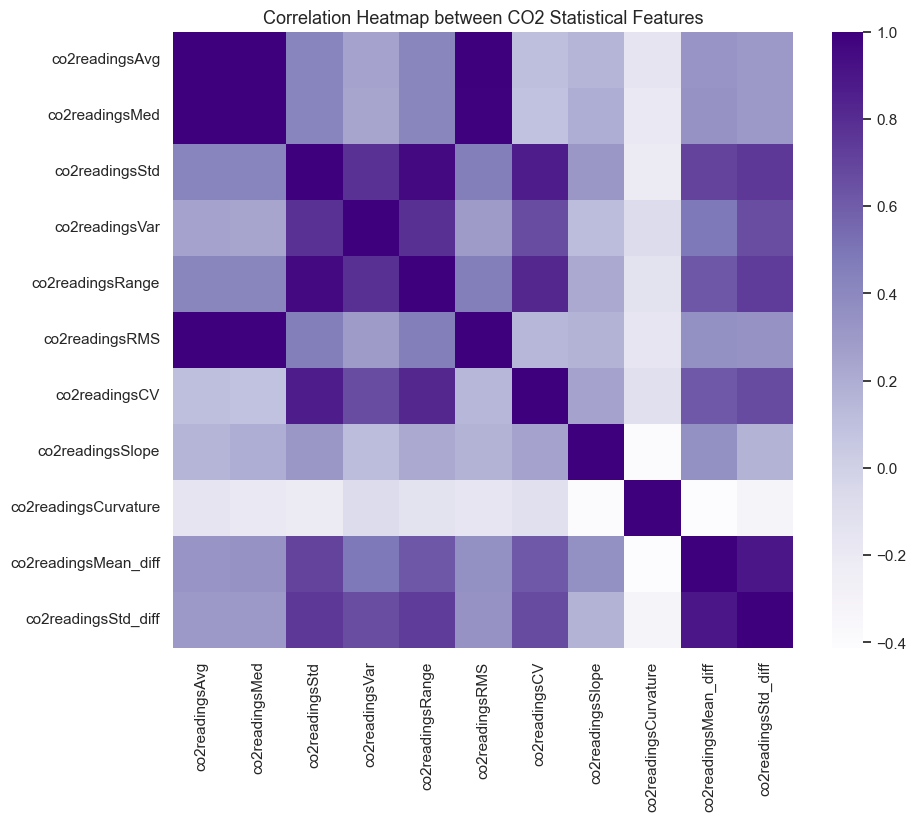

In [18]:
corr = indoorco2map[
    ["co2readingsAvg", "co2readingsMed", "co2readingsStd", "co2readingsVar", 
     "co2readingsRange", "co2readingsRMS", "co2readingsCV", 
     "co2readingsSlope", "co2readingsCurvature", 
     "co2readingsMean_diff", "co2readingsStd_diff"]
].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="Purples", annot=False)
plt.title("Correlation Heatmap between CO2 Statistical Features", fontsize=13)
plt.show()

In [19]:
col_car = [
    "osmKey",
    "ventilation_type",
    "brand",
    "countryName"
]
col_num = [   
    "co2readingsMed",          # CO2 median
    "co2readingsStd",          # Standard deviation
    "co2readingsCV",           # Coefficient of Variation
    "co2readingsSlope",        # Slope
    "co2readingsCurvature",    # Curvature
    "co2readingsStd_diff",     # Variability of changes
    "TimeMed"
]
df_model = indoorco2map[col_num].copy()
df_model

,co2readingsMed,co2readingsStd,co2readingsCV,co2readingsSlope,co2readingsCurvature,co2readingsStd_diff,TimeMed
0,560.0,25.972742,0.046380,0.160476,0.001176,31.442646,560.0
1,661.0,14.302447,0.021638,-0.115000,0.000972,18.833149,661.0
2,931.0,47.622649,0.051152,0.108095,-0.002113,77.502516,931.0
3,1648.0,174.543930,0.105913,1.157619,-0.013601,158.226420,1648.0
4,746.0,75.499966,0.101206,0.490476,-0.003201,61.268988,746.0
...,...,...,...,...,...,...,...
12676,559.0,7.738863,0.013844,0.002929,-0.000123,11.402837,559.0
12677,962.0,89.559415,0.093097,0.435278,-0.000654,73.116239,962.0
12678,815.0,28.898226,0.035458,0.086818,0.000108,23.695780,815.0
12679,627.0,14.895521,0.023757,0.085000,0.000044,13.341664,627.0


In [20]:
# aplly data cleaning class
cleaner = DataCleaner(df_model)
df_model = cleaner("mean")

In [21]:
x = df_model.values
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
df_scaled = pd.DataFrame(x_scaled, columns=col_num)
df_scaled

,co2readingsMed,co2readingsStd,co2readingsCV,co2readingsSlope,co2readingsCurvature,co2readingsStd_diff,TimeMed
0,-0.814471,-0.509631,-0.379638,0.019005,0.681329,-0.247834,-0.814471
1,-0.549516,-0.645679,-0.687459,-0.667026,0.608260,-0.471201,-0.549516
2,0.158780,-0.257245,-0.320267,-0.111442,-0.500247,0.568077,0.158780
3,2.039699,1.222356,0.361012,2.502234,-4.627742,1.998033,2.039699
4,-0.326534,0.067739,0.302462,0.840818,-0.891135,0.280514,-0.326534
...,...,...,...,...,...,...,...
12676,-0.817094,-0.722195,-0.784419,-0.373341,0.214726,-0.602823,-0.817094
12677,0.240103,0.231638,0.201574,0.703355,0.024034,0.490378,0.240103
12678,-0.145525,-0.475527,-0.515519,-0.164429,0.297922,-0.385064,-0.145525
12679,-0.638709,-0.638765,-0.661094,-0.168957,0.274725,-0.568478,-0.638709


In [22]:
ks = list(range(2,11))
inertias = []
silhouette_scores = []
for k in ks:
    kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = kmeans.fit_predict(x_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(x_scaled, labels))

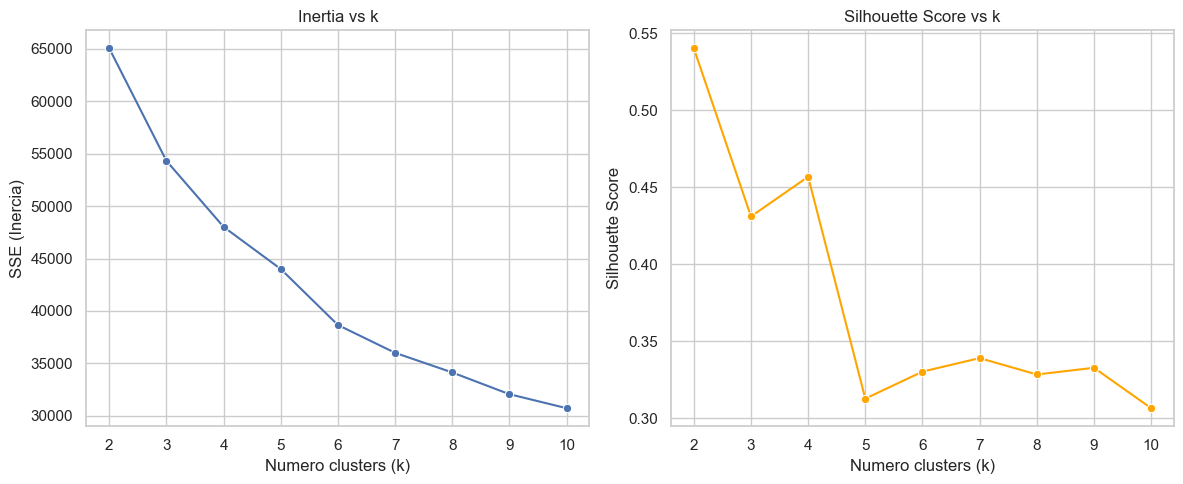

In [23]:
# Plots de inertias y silhouette scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.lineplot(x=ks, y=inertias, marker='o')
plt.title('Inertia vs k')
plt.xlabel('Numero clusters (k)')
plt.ylabel('SSE (Inercia)')

plt.subplot(1, 2, 2)
sns.lineplot(x=ks, y=silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score vs k')
plt.xlabel('Numero clusters (k)')
plt.ylabel('Silhouette Score')
plt.tight_layout()

plt.show()

In [24]:
k_final = 4
kmeans_final = KMeans(n_clusters=k_final, n_init="auto", random_state=42)
labels_final = kmeans_final.fit_predict(x_scaled)

df_model['Cluster'] = labels_final
df_model['Cluster'] = df_model['Cluster'].astype('category')
df_model

,co2readingsMed,co2readingsStd,co2readingsCV,co2readingsSlope,co2readingsCurvature,co2readingsStd_diff,TimeMed,Cluster
0,560.0,25.972742,0.046380,0.160476,0.001176,31.442646,560.0,1
1,661.0,14.302447,0.021638,-0.115000,0.000972,18.833149,661.0,1
2,931.0,47.622649,0.051152,0.108095,-0.002113,77.502516,931.0,1
3,1648.0,174.543930,0.105913,1.157619,-0.013601,158.226420,1648.0,3
4,746.0,75.499966,0.101206,0.490476,-0.003201,61.268988,746.0,1
...,...,...,...,...,...,...,...,...
12676,559.0,7.738863,0.013844,0.002929,-0.000123,11.402837,559.0,1
12677,962.0,89.559415,0.093097,0.435278,-0.000654,73.116239,962.0,1
12678,815.0,28.898226,0.035458,0.086818,0.000108,23.695780,815.0,1
12679,627.0,14.895521,0.023757,0.085000,0.000044,13.341664,627.0,1


In [39]:
pca = PCA(n_components=3, random_state=42)
x_pca = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['Cluster'] = df_model['Cluster'].values
for c in col_car:
	pca_df[c] = indoorco2map[c].values

pca_df


,PC1,PC2,PC3,Cluster,osmKey,ventilation_type,brand,countryName
0,-1.283548,-0.557274,0.057982,1,shop,mechanical,Konsum Leipzig,Germany
1,-1.515126,-0.002508,0.426464,1,shop,mechanical,Konsum Leipzig,Germany
2,0.200862,0.258925,-0.259613,1,shop,both,Konsum Leipzig,Germany
3,4.805170,1.349055,-3.760173,3,shop,mechanical,REWE,Germany
4,0.420599,-0.600765,-1.155731,1,shop,mechanical,Konsum Leipzig,Germany
...,...,...,...,...,...,...,...,...
12676,-1.699718,-0.198803,-0.152192,1,shop,none,REWE,Germany
12677,0.757673,-0.028684,-0.245954,1,shop,none,NORMA,Germany
12678,-0.827617,0.301553,0.064331,1,shop,none,Rewe,Germany
12679,-1.422101,-0.092894,-0.156210,1,amenity,none,Subway,Germany


In [40]:
explained_variance = pca.explained_variance_ratio_.sum()
print(f'Varianza explicada por cada componente principal: {explained_variance:.2%}')

Varianza explicada por cada componente principal: 85.70%


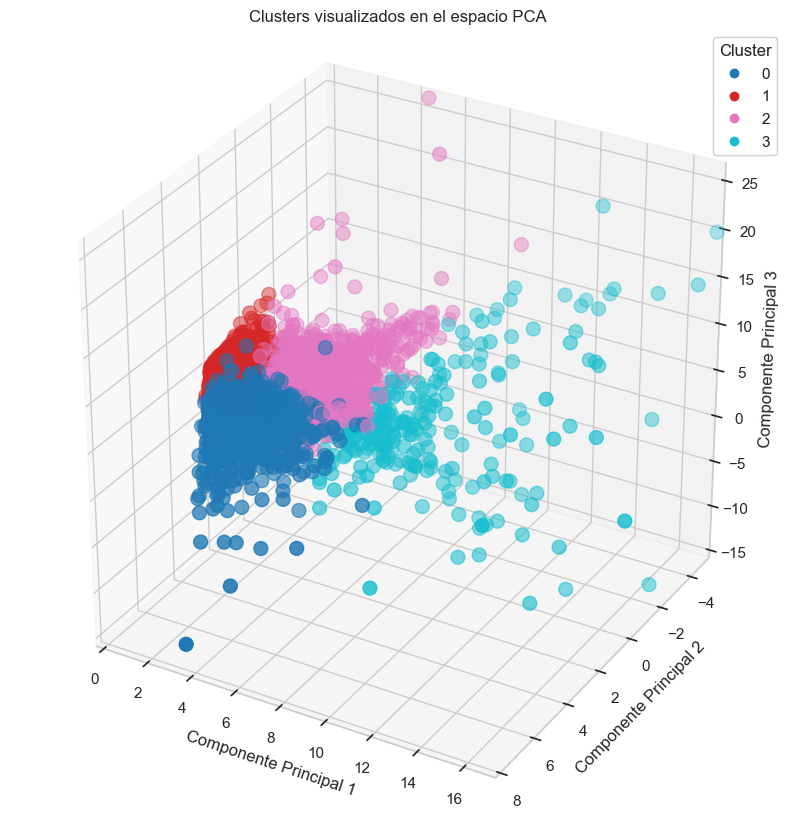

In [70]:
plt.figure(figsize=(10, 20))
ax = plt.subplot(111, projection='3d')

scatter = ax.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    pca_df['PC3'],
    c=pca_df['Cluster'],
    s=100,
    cmap="tab10"
)

plt.title('Clusters visualizados en el espacio PCA')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')

ax.set_xlim(0, 17)
ax.set_ylim(8, -5)     
ax.set_zlim(-15, 26)
ax.set_box_aspect((1, 1, 1))

legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)

plt.show()

In [28]:
df = df_model[col_num].copy()
df['Cluster'] = df_model['Cluster'].values
df[col_car]= indoorco2map[col_car].values
for c in sorted(df['Cluster'].unique()):
    print(f'\n--- Cluster {c} ---')
    display(df[df['Cluster'] == c])


--- Cluster 0 ---


,co2readingsMed,co2readingsStd,co2readingsCV,co2readingsSlope,co2readingsCurvature,co2readingsStd_diff,TimeMed,Cluster,osmKey,ventilation_type,brand,countryName
7,1442.0,47.470412,0.032920,-0.093333,-0.005794,73.312260,1442.0,0,shop,mechanical,REWE,Germany
9,1238.0,64.144925,0.051813,0.223214,0.000036,89.726900,1238.0,0,shop,mechanical,REWE,Germany
14,1376.0,81.686229,0.059365,0.776667,0.004325,83.409757,1376.0,0,shop,none,Lidl,Germany
15,1707.5,179.921665,0.105371,1.526190,-0.009563,102.328100,1707.5,0,shop,mechanical,ALDI Nord,Germany
16,1379.0,25.663983,0.018611,0.241667,-0.001687,29.320428,1379.0,0,shop,none,REWE,Germany
...,...,...,...,...,...,...,...,...,...,...,...,...
12629,1357.0,70.276596,0.051788,0.810000,-0.000714,27.949732,1357.0,0,shop,none,Albert Heijn,Netherlands
12645,1739.0,140.217414,0.080631,0.462821,-0.001943,57.595512,1739.0,0,shop,none,Spar,Austria
12648,2213.5,298.763898,0.134974,0.098016,-0.000023,60.222615,2213.5,0,shop,none,REWE,United States of America
12649,3033.0,112.615097,0.037130,-1.225000,-0.006448,60.577946,3033.0,0,amenity,none,REWE,United States of America



--- Cluster 1 ---


,co2readingsMed,co2readingsStd,co2readingsCV,co2readingsSlope,co2readingsCurvature,co2readingsStd_diff,TimeMed,Cluster,osmKey,ventilation_type,brand,countryName
0,560.0,25.972742,0.046380,0.160476,0.001176,31.442646,560.0,1,shop,mechanical,Konsum Leipzig,Germany
1,661.0,14.302447,0.021638,-0.115000,0.000972,18.833149,661.0,1,shop,mechanical,Konsum Leipzig,Germany
2,931.0,47.622649,0.051152,0.108095,-0.002113,77.502516,931.0,1,shop,both,Konsum Leipzig,Germany
4,746.0,75.499966,0.101206,0.490476,-0.003201,61.268988,746.0,1,shop,mechanical,Konsum Leipzig,Germany
5,483.5,11.682893,0.024163,-0.004343,0.000136,19.601587,483.5,1,amenity,natural,Subway,Germany
...,...,...,...,...,...,...,...,...,...,...,...,...
12676,559.0,7.738863,0.013844,0.002929,-0.000123,11.402837,559.0,1,shop,none,REWE,Germany
12677,962.0,89.559415,0.093097,0.435278,-0.000654,73.116239,962.0,1,shop,none,NORMA,Germany
12678,815.0,28.898226,0.035458,0.086818,0.000108,23.695780,815.0,1,shop,none,Rewe,Germany
12679,627.0,14.895521,0.023757,0.085000,0.000044,13.341664,627.0,1,amenity,none,Subway,Germany



--- Cluster 2 ---


,co2readingsMed,co2readingsStd,co2readingsCV,co2readingsSlope,co2readingsCurvature,co2readingsStd_diff,TimeMed,Cluster,osmKey,ventilation_type,brand,countryName
19,1124.5,148.971381,0.132478,1.439524,-0.002123,29.054432,1124.5,2,shop,mechanical,ALDI Nord,Germany
49,1084.0,98.019182,0.090424,0.691667,-0.010218,127.562485,1084.0,2,shop,mechanical,Konsum Leipzig,Germany
54,1176.0,119.057297,0.101239,1.016667,-0.010833,122.022539,1176.0,2,shop,mechanical,Konsum Leipzig,Germany
56,886.0,102.641231,0.115848,0.869524,-0.005288,66.542017,886.0,2,shop,mechanical,Konsum Leipzig,Germany
69,643.0,83.051022,0.129162,0.700476,-0.003547,59.951314,643.0,2,shop,both,OBI,Germany
...,...,...,...,...,...,...,...,...,...,...,...,...
12643,899.0,190.836814,0.212277,-0.136932,-0.000172,35.168645,899.0,2,tourism,none,REWE,Austria
12658,697.0,139.315310,0.199878,0.351905,-0.001011,89.237616,697.0,2,aeroway,none,REWE,Netherlands
12659,1014.5,175.252389,0.172748,0.981818,-0.001494,41.970889,1014.5,2,shop,none,Edeka,Germany
12661,532.0,112.134562,0.210779,1.223333,0.006984,58.293975,532.0,2,shop,none,Ernsting's family,Germany



--- Cluster 3 ---


,co2readingsMed,co2readingsStd,co2readingsCV,co2readingsSlope,co2readingsCurvature,co2readingsStd_diff,TimeMed,Cluster,osmKey,ventilation_type,brand,countryName
3,1648.0,174.543930,0.105913,1.157619,-0.013601,158.226420,1648.0,3,shop,mechanical,REWE,Germany
10,1420.0,257.995659,0.181687,2.138333,-0.029583,249.354166,1420.0,3,amenity,none,REWE,Germany
29,1891.0,152.284733,0.080531,1.305000,-0.013393,157.046172,1891.0,3,shop,mechanical,REWE,Germany
108,3121.0,869.273908,0.278524,-0.297833,-0.002995,579.190502,3121.0,3,shop,none,Lidl,Germany
112,1331.0,270.080966,0.202916,1.158611,-0.006840,239.298682,1331.0,3,shop,none,REWE,Germany
...,...,...,...,...,...,...,...,...,...,...,...,...
12340,1579.0,544.186946,0.344640,2.822778,-0.014153,253.026154,1579.0,3,shop,none,REWE,Germany
12424,1315.0,741.390108,0.563795,-0.005241,-0.000002,517.586761,1315.0,3,amenity,none,REWE,United States of America
12453,1429.5,415.229346,0.290472,2.176869,-0.006534,144.694399,1429.5,3,shop,none,Lidl,Germany
12515,641.5,443.188824,0.690863,-0.634667,0.001119,409.551267,641.5,3,shop,none,CVS Pharmacy,United States of America


# Modelo Predictivo

In [29]:
target_col = 'Cluster'
numeric_features = col_num
categorical_features = col_car

x = df[numeric_features + categorical_features].copy()
y = df[target_col].astype(str).copy()

mask = y.isin(y.value_counts()[y.value_counts() > 1].index) # Eliminar Categoria de Y con valor 1
x = x[mask]
y = y[mask]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),     # Reemplaza NaN con mediana
    ("scaler", StandardScaler())                       # Escala los valores numéricos
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # Rellena NaN con la moda
    ("onehot", OneHotEncoder(handle_unknown="ignore"))    # Convierte texto a columnas binarias
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=.2, stratify=y, random_state=RandomState)
print(f'Entrenamiento x:{x_train.shape} - Forma:{x_test.shape}\nEntrenamiento y:{y_train.shape} - Forma:{y_test.shape}')

print(y_train.dtypes, y_test.dtypes)
print(y_train.unique(), y_test.unique())


Entrenamiento x:(10144, 11) - Forma:(2537, 11)
Entrenamiento y:(10144,) - Forma:(2537,)
object object
['1' '2' '3' '0'] ['1' '2' '0' '3']


In [30]:
def evaluate_model(model, preprocessor, X_train, X_test, y_train, y_test, title=''):

    # Crear pipeline
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Entrenar
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # Métricas
    print(f"{title}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred, average='weighted'):.4f}")


    # Matriz de confusión
    classes = ['0', '1', '2', '3']
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", linewidths=1, linecolor='black')
    plt.title(f'Matriz de Confusión - {title}', fontsize=14, fontweight='bold')
    plt.xlabel("Predicciones")
    plt.ylabel("Valores reales")
    plt.show()

    # Verifica clases reales y predichas
    print("Clases reales (y_test):", np.unique(y_test))
    print("Clases predic (y_pred):", np.unique(y_pred))

    # Compara totales
    print("\nSuma por fila (reales según matriz):", np.sum(cm, axis=1))
    print("Suma por columna (predic):", np.sum(cm, axis=0))


    print('=============================================================================\n')
    
    return pipe

Logistic Regression
Accuracy:  0.9917
Precision: 0.9917
Recall:    0.9917
F1-score:  0.9917


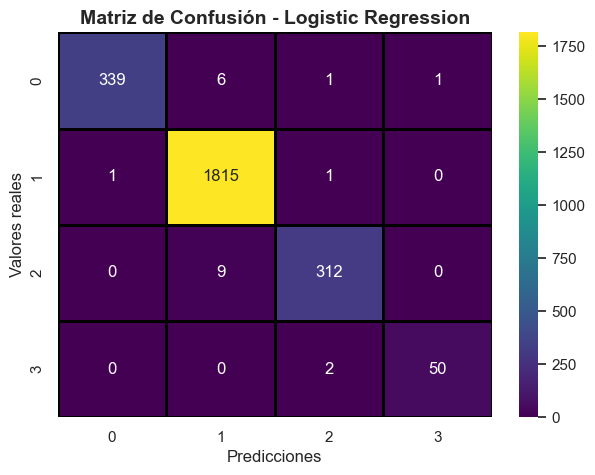

Clases reales (y_test): ['0' '1' '2' '3']
Clases predic (y_pred): ['0' '1' '2' '3']

Suma por fila (reales según matriz): [ 347 1817  321   52]
Suma por columna (predic): [ 340 1830  316   51]

KNN
Accuracy:  0.9452
Precision: 0.9444
Recall:    0.9452
F1-score:  0.9434


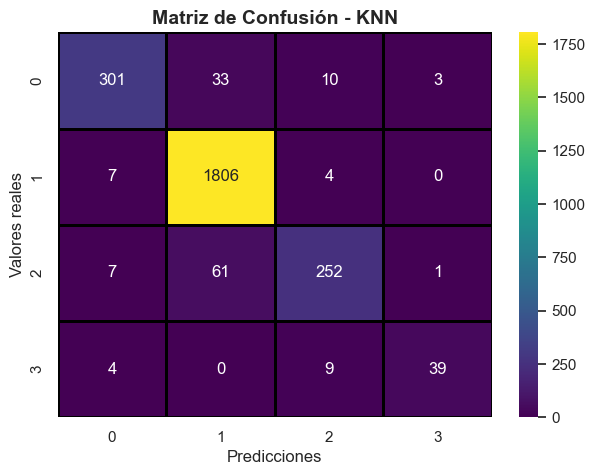

Clases reales (y_test): ['0' '1' '2' '3']
Clases predic (y_pred): ['0' '1' '2' '3']

Suma por fila (reales según matriz): [ 347 1817  321   52]
Suma por columna (predic): [ 319 1900  275   43]

Decision Tree
Accuracy:  0.9732
Precision: 0.9730
Recall:    0.9732
F1-score:  0.9731


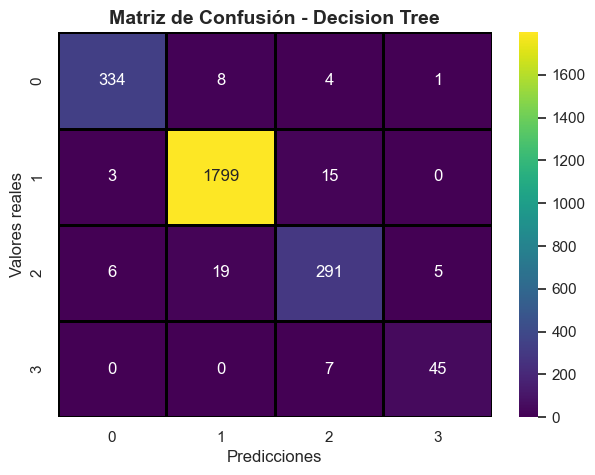

Clases reales (y_test): ['0' '1' '2' '3']
Clases predic (y_pred): ['0' '1' '2' '3']

Suma por fila (reales según matriz): [ 347 1817  321   52]
Suma por columna (predic): [ 343 1826  317   51]

Random Forest
Accuracy:  0.9665
Precision: 0.9661
Recall:    0.9665
F1-score:  0.9658


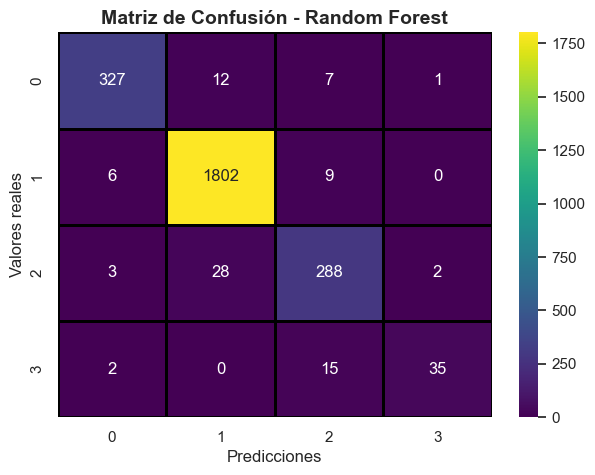

Clases reales (y_test): ['0' '1' '2' '3']
Clases predic (y_pred): ['0' '1' '2' '3']

Suma por fila (reales según matriz): [ 347 1817  321   52]
Suma por columna (predic): [ 338 1842  319   38]

Gradient Boosting
Accuracy:  0.9811
Precision: 0.9810
Recall:    0.9811
F1-score:  0.9809


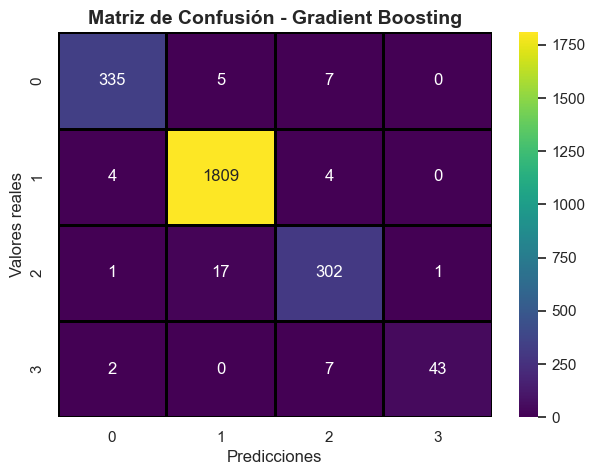

Clases reales (y_test): ['0' '1' '2' '3']
Clases predic (y_pred): ['0' '1' '2' '3']

Suma por fila (reales según matriz): [ 347 1817  321   52]
Suma por columna (predic): [ 342 1831  320   44]



In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, solver='lbfgs'),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=RandomState),
    "Random Forest": RandomForestClassifier(random_state=RandomState),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.1)
}

trained_models = {}

for name, model in models.items():
    trained_models[name] = evaluate_model(model, preprocessor, x_train, x_test, y_train, y_test, title=name)

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RandomState)

def cv_report(model, preprocessor, x, y, scoring='f1_weighted'):
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    scores = cross_val_score(pipeline, x, y, cv=cv, scoring=scoring, n_jobs=-1)
    print(f"{model.__class__.__name__} = {scoring.upper()} Mean: {scores.mean():.4f}, Std: {scores.std():.4f}")
    
    return scores.mean(), scores.std()

In [33]:
trained_models = {}

for name, model in models.items():
    mean_score, std_score = cv_report(model, preprocessor, x, y, scoring='f1_weighted')
    trained_models[name] = {'mean': mean_score, 'std': std_score}

LogisticRegression = F1_WEIGHTED Mean: 0.9916, Std: 0.0018
KNeighborsClassifier = F1_WEIGHTED Mean: 0.9529, Std: 0.0033
DecisionTreeClassifier = F1_WEIGHTED Mean: 0.9726, Std: 0.0031
RandomForestClassifier = F1_WEIGHTED Mean: 0.9725, Std: 0.0025
GradientBoostingClassifier = F1_WEIGHTED Mean: 0.9842, Std: 0.0034


In [34]:
def grid_search_model(model, param_grid, preprocessor, x, y, cv, scoring='f1_weighted'):

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=2
    )

    grid.fit(x, y)

    print(f"\n {model.__class__.__name__} — Mejor resultado:")
    print(f"Mejor puntuación ({scoring}): {grid.best_score_:.4f}")
    print("Mejores hiperparámetros:", grid.best_params_)
    
    return grid.best_estimator_, grid.best_params_, grid.best_score_

In [37]:
param_grids = {
    "Logistic Regression": {
        'classifier__C': [0.1, 1, 10],
        'classifier__solver': ['lbfgs', 'liblinear']
    },
    "KNN": {
        'classifier__n_neighbors': [3, 5, 7, 9],
        'classifier__weights': ['uniform', 'distance'],
        'classifier__p': [1, 2]  # p=1 para Manhattan, p=2 para Euclidean
    },
    "Decision Tree": {
        'classifier__max_depth': [None, 3, 5, 7, 10, 15],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },
    "Random Forest": {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [10, 15],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__max_features': ['sqrt', 'log2'],
        'classifier__bootstrap': [True]
    },
    "Gradient Boosting": {
        'classifier__n_estimators': [50, 200],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__max_depth': [3, 5, 7]
    }
}

In [38]:
best_models = {}

for name, model in models.items():
    print(f"\n================================================================================================")
    best_estimator, best_params, best_score = grid_search_model(
        model=model,
        param_grid=param_grids[name],
        preprocessor=preprocessor,
        x=x,
        y=y,
        cv=cv,
        scoring='f1_weighted'
    )
    best_models[name] = {
        'model': best_estimator,
        'params': best_params,
        'score': best_score
    }


Fitting 5 folds for each of 6 candidates, totalling 30 fits

 LogisticRegression — Mejor resultado:
Mejor puntuación (f1_weighted): 0.9923
Mejores hiperparámetros: {'classifier__C': 10, 'classifier__solver': 'lbfgs'}

Fitting 5 folds for each of 16 candidates, totalling 80 fits

 KNeighborsClassifier — Mejor resultado:
Mejor puntuación (f1_weighted): 0.9574
Mejores hiperparámetros: {'classifier__n_neighbors': 9, 'classifier__p': 2, 'classifier__weights': 'distance'}

Fitting 5 folds for each of 54 candidates, totalling 270 fits

 DecisionTreeClassifier — Mejor resultado:
Mejor puntuación (f1_weighted): 0.9738
Mejores hiperparámetros: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Fitting 5 folds for each of 24 candidates, totalling 120 fits

 RandomForestClassifier — Mejor resultado:
Mejor puntuación (f1_weighted): 0.9551
Mejores hiperparámetros: {'classifier__bootstrap': True, 'classifier__max_depth': 15, 'classifier__max_feature

In [71]:
cv_op = StratifiedKFold(n_splits=5, shuffle=True, random_state=RandomState)

models = {
    "Logistic Regression": LogisticRegression(C=10, solver='lbfgs'),
    "KNN": KNeighborsClassifier(n_neighbors=9, p=2, weights='distance'),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_leaf=1, min_samples_split=2, random_state=RandomState),
    "Random Forest": RandomForestClassifier(bootstrap=True, max_depth=None, max_features='sqrt', min_samples_split=2, n_estimators=100, random_state=RandomState),
    "Gradient Boosting": GradientBoostingClassifier(learning_rate=0.1, max_depth=3, n_estimators=200)
}

results_op = {}
fold_details = {}

for name, model in models.items():
    print(f"\n{name}")
    f1_scores = []

    best_fold = None
    best_score = -np.inf

    # StratifiedKFold manual para obtener los scores individuales
    for fold, (train_idx, test_idx) in enumerate(cv_op.split(x, y), start=1):
        x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", model)
        ])

        pipe.fit(x_train, y_train)
        y_pred = pipe.predict(x_test)

        f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
        f1_scores.append(f1)

        print(f"Fold {fold}: F1_weighted = {f1:.4f}")

        # Guardar mejor fold
        if f1 > best_score:
            best_score = f1
            best_fold = {
                "fold": fold,
                "X_train": x_train,
                "X_test": x_test,
                "y_train": y_train,
                "y_test": y_test,
                "pipe": pipe,
                "y_pred": y_pred
            }

    # Promedio y std general
    mean_f1 = np.mean(f1_scores)
    std_f1 = np.std(f1_scores)
    results_op[name] = (mean_f1, std_f1)
    fold_details[name] = best_fold

    print(f"Mejor fold para {name}: Fold {best_fold['fold']} con F1={best_score:.4f}")
    print(f"Promedio total del modelo: {mean_f1:.4f} ± {std_f1:.4f}")



Logistic Regression
Fold 1: F1_weighted = 0.9941


C:\Users\mlondono\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2: F1_weighted = 0.9917


C:\Users\mlondono\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 3: F1_weighted = 0.9925
Fold 4: F1_weighted = 0.9913


C:\Users\mlondono\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 5: F1_weighted = 0.9933
Mejor fold para Logistic Regression: Fold 1 con F1=0.9941
Promedio total del modelo: 0.9926 ± 0.0010

KNN
Fold 1: F1_weighted = 0.9519
Fold 2: F1_weighted = 0.9610
Fold 3: F1_weighted = 0.9539
Fold 4: F1_weighted = 0.9568
Fold 5: F1_weighted = 0.9632
Mejor fold para KNN: Fold 5 con F1=0.9632
Promedio total del modelo: 0.9574 ± 0.0042

Decision Tree
Fold 1: F1_weighted = 0.9757
Fold 2: F1_weighted = 0.9731
Fold 3: F1_weighted = 0.9727
Fold 4: F1_weighted = 0.9721
Fold 5: F1_weighted = 0.9751
Mejor fold para Decision Tree: Fold 1 con F1=0.9757
Promedio total del modelo: 0.9738 ± 0.0014

Random Forest
Fold 1: F1_weighted = 0.9726
Fold 2: F1_weighted = 0.9752
Fold 3: F1_weighted = 0.9687
Fold 4: F1_weighted = 0.9709
Fold 5: F1_weighted = 0.9750
Mejor fold para Random Forest: Fold 2 con F1=0.9752
Promedio total del modelo: 0.9725 ± 0.0025

Gradient Boosting
Fold 1: F1_weighted = 0.9843
Fold 2: F1_weighted = 0.9860
Fold 3: F1_weighted = 0.9793
Fold 4: F1_weighted


Evaluando el mejor fold de Logistic Regression (Fold 1)
Logistic Regression - Fold 1
Accuracy:  0.9941
Precision: 0.9941
Recall:    0.9941
F1-score:  0.9941


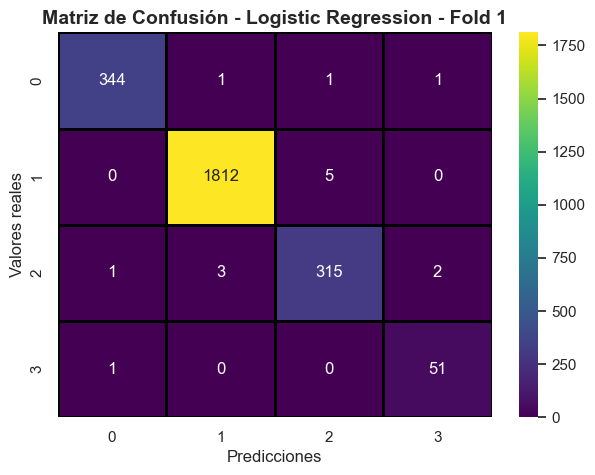

Clases reales (y_test): ['0' '1' '2' '3']
Clases predic (y_pred): ['0' '1' '2' '3']

Suma por fila (reales según matriz): [ 347 1817  321   52]
Suma por columna (predic): [ 346 1816  321   54]


Evaluando el mejor fold de KNN (Fold 5)
KNN - Fold 5
Accuracy:  0.9641
Precision: 0.9639
Recall:    0.9641
F1-score:  0.9632


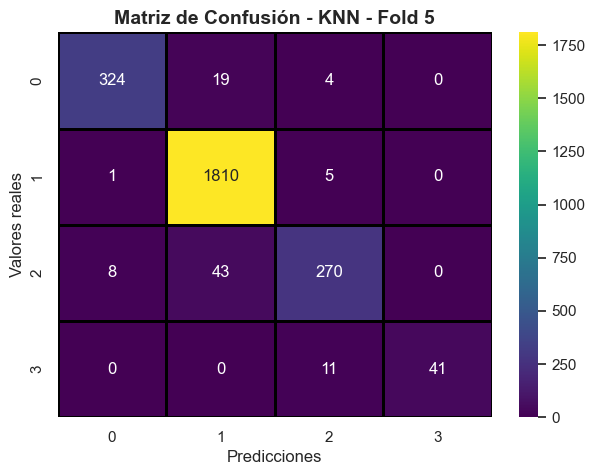

Clases reales (y_test): ['0' '1' '2' '3']
Clases predic (y_pred): ['0' '1' '2' '3']

Suma por fila (reales según matriz): [ 347 1816  321   52]
Suma por columna (predic): [ 333 1872  290   41]


Evaluando el mejor fold de Decision Tree (Fold 1)
Decision Tree - Fold 1
Accuracy:  0.9756
Precision: 0.9759
Recall:    0.9756
F1-score:  0.9757


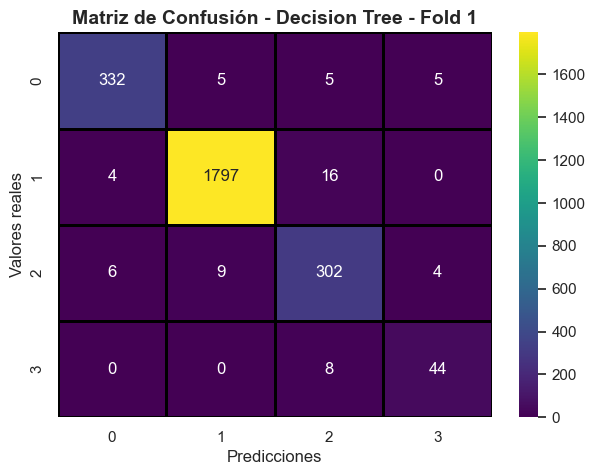

Clases reales (y_test): ['0' '1' '2' '3']
Clases predic (y_pred): ['0' '1' '2' '3']

Suma por fila (reales según matriz): [ 347 1817  321   52]
Suma por columna (predic): [ 342 1811  331   53]


Evaluando el mejor fold de Random Forest (Fold 2)
Random Forest - Fold 2
Accuracy:  0.9756
Precision: 0.9757
Recall:    0.9756
F1-score:  0.9752


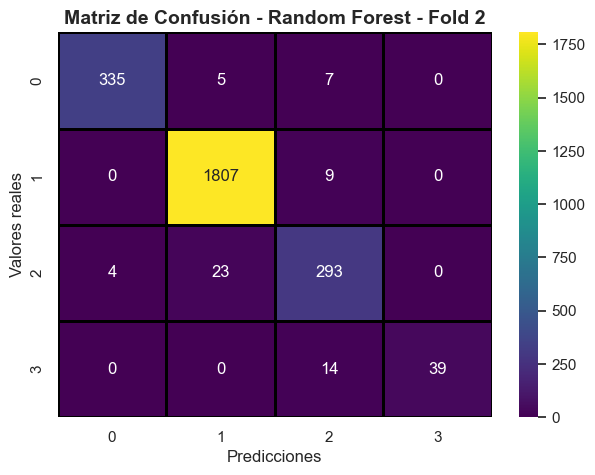

Clases reales (y_test): ['0' '1' '2' '3']
Clases predic (y_pred): ['0' '1' '2' '3']

Suma por fila (reales según matriz): [ 347 1816  320   53]
Suma por columna (predic): [ 339 1835  323   39]


Evaluando el mejor fold de Gradient Boosting (Fold 4)
Gradient Boosting - Fold 4
Accuracy:  0.9909
Precision: 0.9909
Recall:    0.9909
F1-score:  0.9909


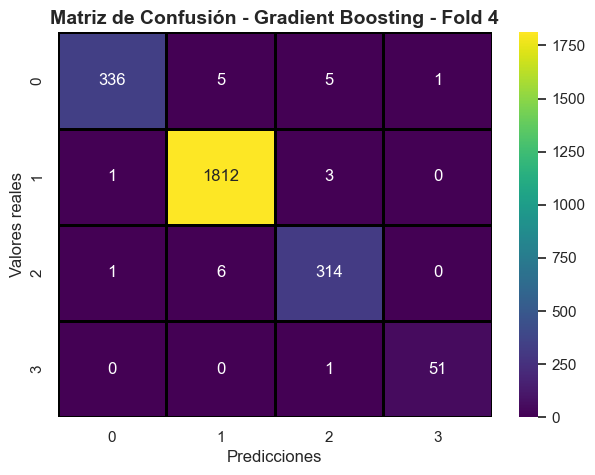

Clases reales (y_test): ['0' '1' '2' '3']
Clases predic (y_pred): ['0' '1' '2' '3']

Suma por fila (reales según matriz): [ 347 1816  321   52]
Suma por columna (predic): [ 338 1823  323   52]



In [72]:
for name, best in fold_details.items():
    print(f"\nEvaluando el mejor fold de {name} (Fold {best['fold']})")
    evaluate_model(
        best["pipe"].named_steps["classifier"],   # modelo
        best["pipe"].named_steps["preprocessor"], # preprocessor
        best["X_train"], best["X_test"],
        best["y_train"], best["y_test"],
        title=f"{name} - Fold {best['fold']}"
    )

In [78]:
df['Cluster'].value_counts()


Cluster
1    9081
0    1736
2    1603
3     261
Name: count, dtype: int64

In [73]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)


         co2readingsMed  co2readingsStd  co2readingsCV  co2readingsSlope  \
Cluster                                                                    
0           1532.379896       83.125101       0.054294          0.187601   
1            714.567724       38.459878       0.053915          0.080193   
2            947.412352      178.992211       0.193274          0.347577   
3           1419.818008      395.578686       0.311992          1.253453   

         co2readingsCurvature  co2readingsStd_diff      TimeMed  
Cluster                                                          
0                   -0.001113            51.967032  1532.379896  
1                   -0.000335            28.924833   714.567724  
2                   -0.000993            94.855925   947.412352  
3                   -0.009848           272.818894  1419.818008  


C:\Users\mlondono\AppData\Local\Temp\ipykernel_19572\2095332276.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_summary = df.groupby('Cluster').mean(numeric_only=True)


In [75]:
cluster_norm = cluster_summary.copy()
cluster_norm = (cluster_norm - cluster_norm.mean()) / cluster_norm.std()
cluster_norm

,co2readingsMed,co2readingsStd,co2readingsCV,co2readingsSlope,co2readingsCurvature,co2readingsStd_diff,TimeMed
Cluster,,,,,,,
0,0.978574,-0.572131,-0.796122,-0.522086,0.432541,-0.544335,0.978574
1,-1.133926,-0.853214,-0.799172,-0.722641,0.604183,-0.752773,-1.133926
2,-0.532462,0.031171,0.320661,-0.223374,0.459000,-0.156365,-0.532462
3,0.687814,1.394174,1.274633,1.468101,-1.495724,1.453473,0.687814


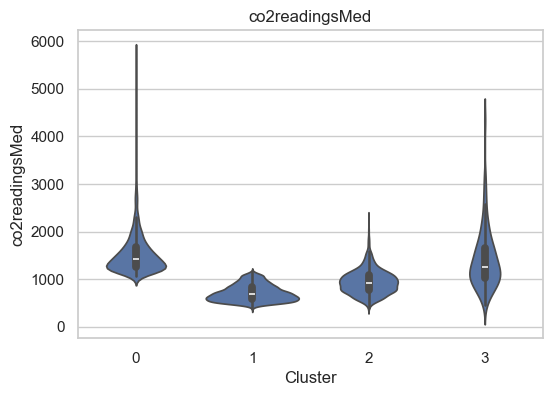

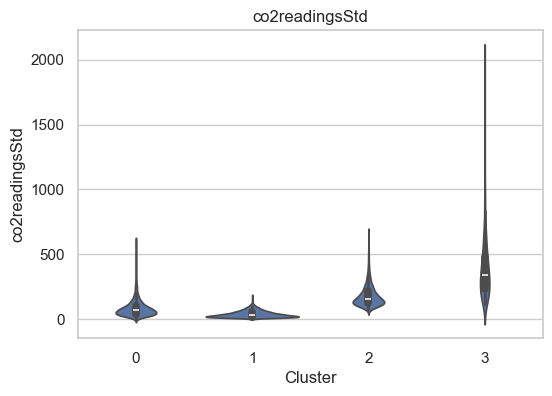

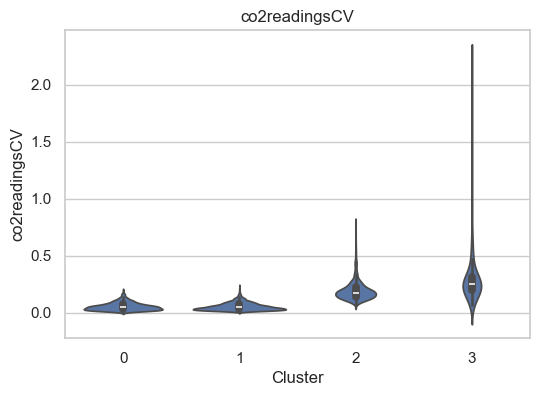

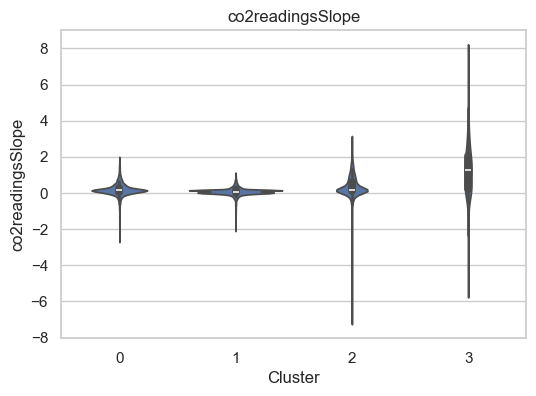

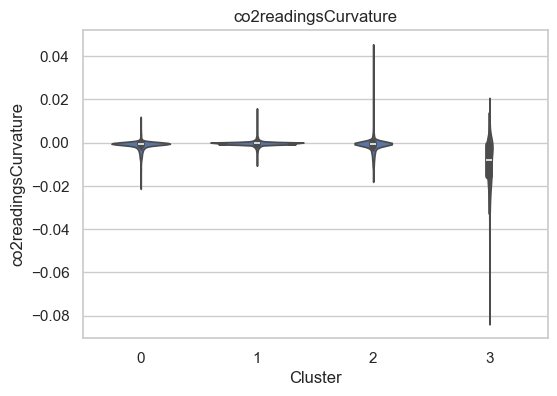

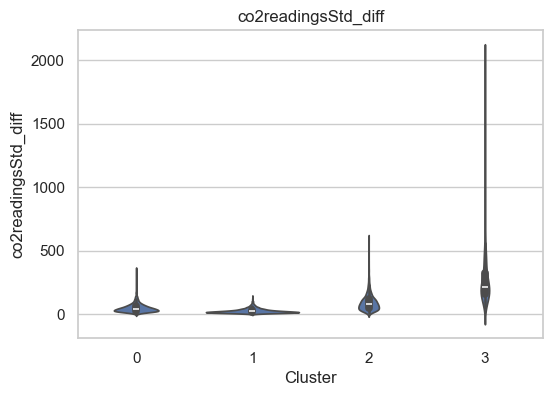

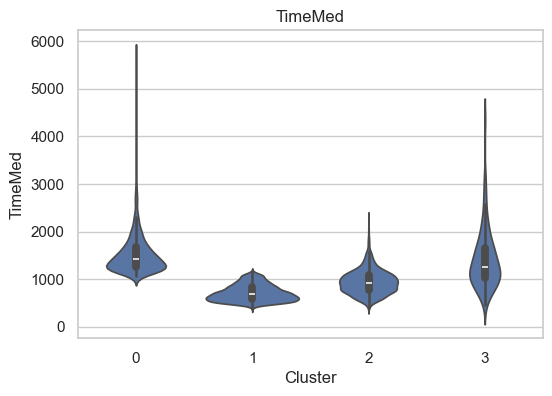

In [76]:
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(6,4))
    sns.violinplot(data=df, x='Cluster', y=col)
    plt.title(col)
    plt.show()

| Cluster | Característica principal  | Interpretación                                                  |
| ------- | ------------------------- | --------------------------------------------------------------- |
| **1**   | Bajo CO₂, muy estable     | *Condiciones normales, ventilación buena*                       |
| **2**   | CO₂ medio, muy variable   | *Ambiente dinámico: entradas/salidas, ventilación intermitente* |
| **3**   | CO₂ alto y muy variable   | *Eventos críticos: acumulación rápida, crisis de ventilación*   |
| **0**   | CO₂ muy alto pero estable | *Mala ventilación sostenida; problema estructural*              |
